In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

2026-07-30 02:28:41.092769: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-30 02:28:41.117639: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-30 02:28:41.117662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-30 02:28:41.118318: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-30 02:28:41.122132: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-30 02:28:41.122526: I tensorflow/core/platform/cpu_feature_guard.cc:1

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-07-30 02:28:41.675312: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from callbacks import all_callbacks
from tensorflow.keras.layers import Activation
from qkeras.qlayers import QDense, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.initializers import LecunUniform

In [4]:
model = Sequential()

# First hidden layer
model.add(
    QDense(
        64,
        input_shape=(8,),
        name='fc1',
        kernel_quantizer=quantized_bits(6, 2, alpha=1),
        bias_quantizer=quantized_bits(6, 2, alpha=1),
        kernel_initializer=LecunUniform(),
        kernel_regularizer=l1(0.001),
    )
)
model.add(BatchNormalization())
model.add(QActivation(activation=quantized_relu(6, 2), name='relu1'))
model.add(Dropout(0.2))

# Second hidden layer
model.add(
    QDense(
        32,
        name='fc2',
        kernel_quantizer=quantized_bits(6, 2, alpha=1),
        bias_quantizer=quantized_bits(6, 2, alpha=1),
        kernel_initializer=LecunUniform(),
        kernel_regularizer=l1(0.001),
    )
)
model.add(QActivation(activation=quantized_relu(6, 2), name='relu2'))
model.add(Dropout(0.2))

# Output layer
model.add(
    QDense(
        1,
        name='output',
        kernel_quantizer=quantized_bits(6, 2, alpha=1),
        bias_quantizer=quantized_bits(6, 2, alpha=1),
        kernel_initializer=LecunUniform(),
        kernel_regularizer=l1(0.001),
    )
)
model.add(Activation('sigmoid', name='sigmoid'))

In [5]:
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning
import tensorflow_model_optimization as tfmot

# batch_size = 32
NSTEPS = int(np.ceil(X_train_val.shape[0] / 32))

pruning_params = {
    'pruning_schedule':tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.0,
    final_sparsity=0.5,
    begin_step=NSTEPS * 2,
    end_step=NSTEPS * 15,
    frequency=NSTEPS)
}

model = prune.prune_low_magnitude(model, **pruning_params)

In [6]:
train = True

if train:
    import numpy as np
    import tensorflow as tf
    import tensorflow_model_optimization as tfmot

    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.models import load_model
    from tensorflow_model_optimization.sparsity.keras import strip_pruning
    from sklearn.utils.class_weight import compute_class_weight
    from sklearn.metrics import accuracy_score

    adam = Adam(learning_rate=0.001)

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    )

    # Compute class weights
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_val),
        y=y_train_val
    )
    class_weights_dict = dict(enumerate(weights))

    # Compile model
    model.compile(
        optimizer=adam,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # hls4ml callbacks
    hls_callbacks = all_callbacks(
        stop_patience=50,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=1e-6,
        lr_cooldown=2,
        lr_minimum=1e-7,
        outputDir='model_3',
    )

    # Pruning callback
    pruning_callback = tfmot.sparsity.keras.UpdatePruningStep()

    hls_callbacks.callbacks.append(early_stop)
    hls_callbacks.callbacks.append(pruning_callback)

    # Train
    model.fit(
        X_train_val,
        y_train_val,
        batch_size=128,
        epochs=2000,
        validation_split=0.25,
        shuffle=True,
        callbacks=hls_callbacks.callbacks,
        class_weight=class_weights_dict,
        verbose=1
    )

    # Strip pruning wrappers
    model = strip_pruning(model)

    # Save stripped model
    model.save('model_3/KERAS_check_best_model.keras')

else:
    from tensorflow.keras.models import load_model
    from qkeras.utils import _add_supported_quantized_objects

    co = {}
    _add_supported_quantized_objects(co)

    model = load_model(
        'model_3/KERAS_check_best_model.keras',
        custom_objects=co
    )

# Predictions
y_keras = model.predict(X_test)

y_pred = (y_keras > 0.5).astype(int).ravel()

print("Final accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/2000


/home/tvangos/.local/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


1/4 [======>.......................] - ETA: 6s - loss: 1.1189 - accuracy: 0.5547
***callbacks***
saving losses to model_3/losses.log

Epoch 1: val_loss improved from inf to 1.03542, saving model to model_3/KERAS_check_best_model.h5

Epoch 1: val_loss improved from inf to 1.03542, saving model to model_3/KERAS_check_best_model_weights.h5

Epoch 1: saving model to model_3/KERAS_check_model_last.h5

Epoch 1: saving model to model_3/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 2s 111ms/step - loss: 1.0624 - accuracy: 0.5804 - val_loss: 1.0354 - val_accuracy: 0.6364 - lr: 0.0010
Epoch 2/2000
1/4 [======>.......................] - ETA: 0s - loss: 1.0418 - accuracy: 0.5625WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0011s vs `on_train_batch_end` time: 0.0050s). Check your callbacks.

***callbacks***
saving losses to model_3/losses.log

Epoch 2: val_loss improved from 1.03542 to 0.995

/home/tvangos/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 3: saving model to model_3/KERAS_check_model_last.h5

Epoch 3: saving model to model_3/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 0s 28ms/step - loss: 1.0019 - accuracy: 0.6783 - val_loss: 0.9601 - val_accuracy: 0.7727 - lr: 0.0010
Epoch 4/2000
1/4 [======>.......................] - ETA: 0s - loss: 1.0112 - accuracy: 0.6641
***callbacks***
saving losses to model_3/losses.log

Epoch 4: val_loss improved from 0.96009 to 0.92327, saving model to model_3/KERAS_check_best_model.h5

Epoch 4: val_loss improved from 0.96009 to 0.92327, saving model to model_3/KERAS_check_best_model_weights.h5

Epoch 4: saving model to model_3/KERAS_check_model_last.h5

Epoch 4: saving model to model_3/KERAS_check_model_last_weights.h5

***callbacks end***

4/4 [==============================] - 0s 28ms/step - loss: 0.9692 - accuracy: 0.6913 - val_loss: 0.9233 - val_accuracy: 0.7922 - lr: 0.0010
Epoch 5/2000
1/4 [======>.......................] - ETA: 0

In [7]:
import hls4ml
import plotting
import numpy as np

def numerical(model, hls_model, X):
    X = np.ascontiguousarray(X)

    y_keras = model.predict(X)
    y_hls = hls_model.predict(X)

    diff = y_keras - y_hls

    print("Max abs diff:", np.max(np.abs(diff)))
    print("Mean abs diff:", np.mean(np.abs(diff)))

    return y_keras, y_hls, diff

# Generate the base configuration
config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='name',
    backend='Vitis'
)

# Global settings
config['Model']['Precision'] = 'ap_fixed<6,3>'
config['Model']['ReuseFactor'] = 16

# Layer-wise precision
for layer in config['LayerName']:

    config['LayerName'][layer]['Trace'] = True

    if 'Precision' not in config['LayerName'][layer]:
        config['LayerName'][layer]['Precision'] = {}

    # Weights and biases
    config['LayerName'][layer]['Precision']['weight'] = 'ap_fixed<4,1>'
    config['LayerName'][layer]['Precision']['bias'] = 'ap_fixed<4,1>'

    # Layer outputs
    config['LayerName'][layer]['Precision']['result'] = 'ap_fixed<6,3>'

# Sigmoid lookup tables
config['LayerName']['sigmoid']['exp_table_t'] = 'ap_fixed<6,3>'
config['LayerName']['sigmoid']['inv_table_t'] = 'ap_fixed<6,3>'

print("-----------------------------------")
plotting.print_dict(config)
print("-----------------------------------")

# Convert
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    backend='Vitis',
    output_dir='model_3/hls4ml_prj',
    part='xc7z020-clg484-1'
)

hls_model.compile()

# Predictions
X_test_contig = np.ascontiguousarray(X_test)

y_qkeras = model.predict(X_test_contig)
y_hls = hls_model.predict(X_test_contig)

# Save predictions
np.save('model_3/y_qkeras.npy', y_qkeras)
np.save('model_3/y_hls.npy', y_hls)

# (Optional) Numerical comparison
numerical(model=model, hls_model=hls_model, X=X_test[:1000])

# (Optional) Visualize the generated HLS model
hls4ml.utils.plot_model(
    hls_model,
    show_shapes=True,
    show_precision=True
)

-----------------------------------
Model
  Precision:         ap_fixed<6,3>
  ReuseFactor:       16
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  fc1_input
    Trace:           True
    Precision
      result:        ap_fixed<6,3>
      weight:        ap_fixed<4,1>
      bias:          ap_fixed<4,1>
  fc1
    Trace:           True
    Precision
      result:        ap_fixed<6,3>
      weight:        ap_fixed<4,1>
      bias:          ap_fixed<4,1>
      accum:         auto
    ReuseFactor:     1
  fc1_linear
    Trace:           True
    Precision
      result:        ap_fixed<6,3>
      table:         fixed<18,8,TRN,WRAP,0>
      weight:        ap_fixed<4,1>
      bias:          ap_fixed<4,1>
    ReuseFactor:     1
    TableSize:       1024
  batch_normalization
    Trace:           True
    Precision
      result:        ap_fixed<6,3>
      scale:         auto
      bias:          ap_fixed<4,1>
      weight:        ap_fixed<4,1>


/home/tvangos/.local/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


5/5 [==============================] - 0s 817us/step
Max abs diff: 0.8689496023580432
Mean abs diff: 0.09175194507803429


5/5 [==============================] - 0s 818us/step
Accuracy baseline           : 0.7857
Accuracy pruned, quantized  : 0.7468
Accuracy hls4ml             : 0.7662


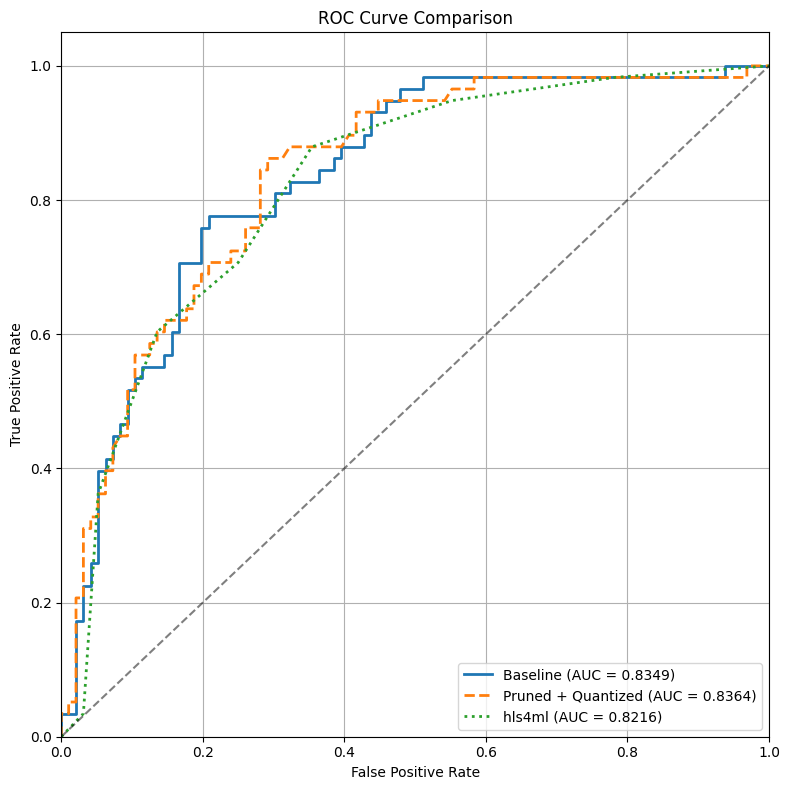

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, roc_curve, auc
from qkeras.utils import _add_supported_quantized_objects

# Load baseline model
model_ref = load_model('model_1/KERAS_check_best_model.h5')

# If loading a QKeras model instead:
# co = {}
# _add_supported_quantized_objects(co)
# model_ref = load_model('model_1/KERAS_check_best_model.keras',
#                        custom_objects=co)

# Predictions
y_ref = model_ref.predict(X_test).ravel()
y_qkeras = np.nan_to_num(y_qkeras.ravel(), nan=0.0)
y_hls = np.nan_to_num(y_hls.ravel(), nan=0.0)

# Accuracy
print(f"Accuracy baseline           : {accuracy_score(y_test, (y_ref > 0.5).astype(int)):.4f}")
print(f"Accuracy pruned, quantized  : {accuracy_score(y_test, (y_qkeras > 0.5).astype(int)):.4f}")
print(f"Accuracy hls4ml             : {accuracy_score(y_test, (y_hls > 0.5).astype(int)):.4f}")

# ROC curves
fpr_ref, tpr_ref, _ = roc_curve(y_test, y_ref)
roc_auc_ref = auc(fpr_ref, tpr_ref)

fpr_q, tpr_q, _ = roc_curve(y_test, y_qkeras)
roc_auc_q = auc(fpr_q, tpr_q)

fpr_hls, tpr_hls, _ = roc_curve(y_test, y_hls)
roc_auc_hls = auc(fpr_hls, tpr_hls)

# Plot
plt.figure(figsize=(8, 8))

plt.plot(fpr_ref, tpr_ref,
         label=f'Baseline (AUC = {roc_auc_ref:.4f})',
         linewidth=2)

plt.plot(fpr_q, tpr_q,
         '--',
         label=f'Pruned + Quantized (AUC = {roc_auc_q:.4f})',
         linewidth=2)

plt.plot(fpr_hls, tpr_hls,
         ':',
         label=f'hls4ml (AUC = {roc_auc_hls:.4f})',
         linewidth=2)

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.grid(True)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [9]:
hls_model.build(csim=False)


****** vitis-run v2023.2 (64-bit)
  **** SW Build 4026344 on 2023-10-11-15:42:10
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/tvangos/Desktop/UTH/CPU_design/src/model_3/hls4ml_prj/build_prj.tcl -work_dir /home/tvangos/Desktop/UTH/CPU_design/src/model_3/hls4ml_prj

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.646',
  'BestLatency': '25',
  'WorstLatency': '25',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '1',
  'DSP': '16',
  'FF': '11831',
  'LUT': '15484',
  'URAM': '0',
  'AvailableBRAM_18K': '280',
  'AvailableDSP': '220',
  'AvailableFF': '106400',
  'AvailableLUT': '53200',
  'AvailableURAM': '0'}}

In [10]:
#part 4 report
hls4ml.report.read_vivado_report('model_3/hls4ml_prj')

Found 1 solution(s) in model_3/hls4ml_prj/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Thu Jul 30 02:29:54 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: zynq
* Target device:  xc7z020-clg484-1


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.646 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+---------+----------+-------

In [11]:
#part 3 report
hls4ml.report.read_vivado_report('pruned_model_1/hls4ml_prj')


Found 1 solution(s) in pruned_model_1/hls4ml_prj/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Sun Jul 26 16:28:51 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu250-figd2104-2L-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.480 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+---------+

In [12]:
#part 2 report
hls4ml.report.read_vivado_report('quantized_model_1/hls4ml_prj')

Found 1 solution(s) in quantized_model_1/hls4ml_prj/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Sun Jul 26 16:26:18 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu250-figd2104-2L-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.647 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +---------+-

In [13]:
#part 1 report
hls4ml.report.read_vivado_report('model_1/hls4ml_prj')

Found 1 solution(s) in model_1/hls4ml_prj/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Sun Jul 26 16:24:15 2026

* Version:        2023.2 (Build 4023990 on Oct 11 2023)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu250-figd2104-2L-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.647 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+---------+-------